In [150]:
import torch
import matplotlib.pyplot as plt
import numpy as np

In [151]:
n = 10
probs = np.random.rand(n)
eps = 0.2
record = np.zeros((n,2))
rewards = [0]

In [152]:
def get_best_reward(record):
    index = np.argmax(record[:,1],axis=0)

    return index

def get_reward(prob, iteration = n):
    sample = np.random.rand(iteration)
    return sum(sample < prob)
    
def update_record(record,choice,r):
    record[choice,1] = (record[choice,1] * record[choice,0] + r) / (record[choice,0]+1)
    record[choice,0] += 1

    return record

In [153]:
# fig,ax = plt.subplots(1,1)

# for i in range(1000):
#     if np.random.rand() > eps:
#         choice = get_best_reward(record)
#     else:
#         choice = np.random.randint(n)
#     r = get_reward(probs[choice])
#     record = update_record(record,choice,r)
#     rewards.append((rewards[-1] * (i) + r) / (i + 1) )

# ax.scatter(np.arange(len(rewards)),rewards)


In [154]:
def softmax(av,tau=1.12):
    return np.exp(av/tau) / np.sum(np.exp(av/tau))




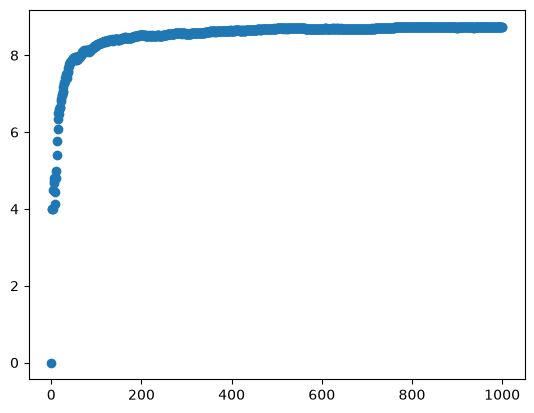

In [155]:
fig,ax = plt.subplots(1,1)

for i in range(1000):
    p = softmax(record[:,1])
    choice = np.random.choice(np.arange(n),p=p)
    r = get_reward(probs[choice])
    record = update_record(record,choice,r)
    rewards.append((rewards[-1] * (i) + r) / (i + 1) )

ax.scatter(np.arange(len(rewards)),rewards)